# **Data-driven analysis of seismic phase using circular statistics**

Akshika Rohatgi, Andrey Bakulin, and Sergey Fomel


# **Abstract**

Recognizing seismic phase as a primary attribute in seismic processing workflows, we apply circular statistics, a robust data-driven approach for correcting phase distortions in prestack seismic data. Unlike traditional linear methods that struggle with wrapped phase and often defer phase diagnostics to the final processing stages, the proposed approach treats phase as a circular variable.

We compute the circular mean, variance, and von Mises concentration parameter directly from phase ensembles in the frequency domain. These parameters provide insights into phase stability and coherence without needing phase unwrapping or wavelet assumptions.

Synthetic tests using additive and multiplicative noise models confirm that phase distributions follow the von Mises distribution—an analog of the normal distribution for circular variables—with circular statistics reliably tracking the true phase even in low-signal-quality scenarios.

Field examples demonstrate how this framework can map phase behavior across frequency and offset, enabling the detection of coherence bands and assessing the impact of each processing step on phase fidelity. The proposed approach can be particularly valuable in land acquisition, where prestack data often exhibit a low signal-to-noise ratio. Circular statistics allow us to evaluate phase integrity at each frequency, facilitating novel data conditioning and acquisition design strategies.

# **Introduction**

The phase component of seismic signals contains critical information for accurate subsurface imaging and for identifying structural and stratigraphic features (Oppenheim and Lim, 1981; Lichman, 1999; Ulrych et al., 2007; van der Baan and Fomel, 2009; Greer et al., 2019). In many applications—particularly migration, coherence analysis, and inversion—consistent phase alignment can be as important as, or even more important than, amplitude fidelity (Xie et al., 2016; Holt and Lubrano, 2020; Bakulin et al., 2022a, 2022b). As acquisition and processing move toward denser spatial sampling and larger data volumes, statistical analysis of phase variability becomes both feasible and increasingly necessary.

Conventional processing methods, including noise attenuation, surface-consistent scaling, and deconvolution (Taner and Koehler, 1981; Cary and Lorentz, 1993; Chan and Stewart, 1994; Meunier, 1999; Liu et al., 2006), often do not fully account for the true statistical nature of seismic phase, particularly under low signal-to-noise ratio (S/N) conditions or significant wavelet perturbations. A fundamental challenge is that phase is a circular variable bounded within [−π, π], violating the assumptions underlying standard linear statistics. As a result, conventional measures such as linear means and variances can lead to misleading interpretations (Bakulin et al., 2024).

This paper introduces a robust analytical framework based on circular statistics (Mardia and Jupp, 1999) to characterize seismic phase distributions across frequency. Treating phase as a circular random variable allows us to quantify both its average behavior (circular mean) and its dispersion or concentration (via the von Mises concentration parameter, κ), which can be interpreted as a frequency-dependent analog of S/N. This shift from linear to circular statistical analysis provides a more meaningful description of phase variability, particularly for noisy land data.

Unlike traditional workflows that evaluate phase quality primarily in stacked or migrated images, the proposed framework enables diagnostics directly on raw prestack data. Phase integrity can therefore be monitored throughout each processing stage. Because the analysis is performed frequency by frequency, it offers a powerful tool for assessing how processing affects phase fidelity—information that amplitude-based or stack-based S/N metrics often fail to capture.

This capability is especially important in land acquisition, where prestack data commonly exhibit low S/N, making conventional quality measures unreliable (Bakulin et al., 2022a). By directly evaluating phase coherence across frequency, the framework complements frequency-dependent processing approaches (Retailleau et al., 2014; Bakulin et al., 2019) and supports emerging techniques such as time–frequency phase masking (Bakulin et al., 2023), which estimate signal phase through local stacking. Here, we extend these ideas by analyzing the full statistical distribution of phase to estimate signal phase and quantify noise-induced perturbations.

We propose that phase statistics should be treated as primary diagnostic attributes, monitored alongside conventional S/N throughout the processing workflow. Such diagnostics can inform acquisition design, bandwidth evaluation, and the development of phase-aware processing strategies. Tests on both synthetic and field data demonstrate that the proposed approach yields stable, interpretable estimates of phase behavior even under severe noise conditions.

# **When phase misleads: A visual case for rethinking analysis**

We begin with a simple yet illustrative synthetic example that highlights the challenges of phase analysis in noisy environments. Figure 1 shows a seismic ensemble containing three flat reflectors, each contaminated by additive Gaussian noise. Two noise levels are considered: −2 dB and −10 dB S/N. The underlying signal is identical across all traces, so any phase variability arises solely from noise.

Figures 1c and 1d present histograms of the estimated phase at 40 Hz and 60 Hz on a linear scale. In the absence of noise, the phase would be constant across traces, collapsing the distribution into a narrow spike (dashed red line). Even moderate noise, however, spreads the phase distribution. As the noise level increases, the contamination becomes more severe.

At 40 Hz (Figure 1c), the distribution appears roughly symmetric, suggesting small random perturbations around the true phase. Closer inspection, however, reveals that the distribution is broader and less centered than expected. At 60 Hz (Figure 1d), the effect is more pronounced: the phase distribution becomes bimodal, splitting into two distinct peaks.

This behavior is not simply random scatter but reflects the limitations of linear statistical analysis applied to circular variables. Linear methods implicitly treat phase as an ordinary real-valued quantity, ignoring its periodic nature. As a result, they can produce misleading interpretations when phase wraps around the [−π, π] interval, especially under low S/N conditions.

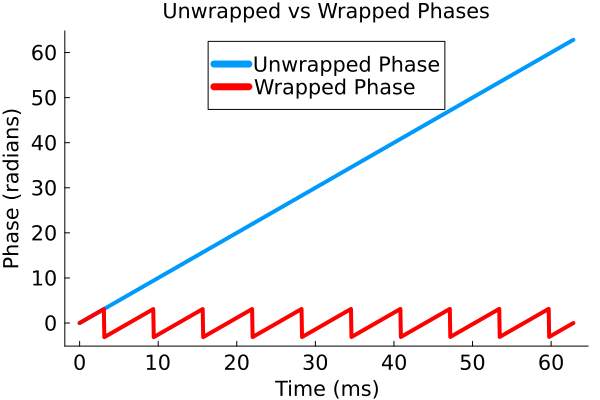

In [1]:
begin
	using Plots
	
	x = range(0, 20π, length=1000)  
	wrapped_phase = mod.(x .+ π, 2π) .- π  
	unwrapped_phase = x  
	
	plot(x, unwrapped_phase, label="Unwrapped Phase", lw=4, xlabel="Time (ms)", ylabel="Phase (radians)", legend=:top, fontsize=14, labelfont=14, legendfont=14, tickfont=14, xguidefontsize=14, yguidefontsize=14)
	
	plot!(x, wrapped_phase, label="Wrapped Phase", lw=4, color=:red, fontsize=14, labelfont=14, legendfont=14, tickfont=14, xguidefontsize=14, yguidefontsize=14, grid=false, title="Unwrapped vs Wrapped Phases")
end

# **From confusion to clarity: Circular statistics explained visually**

To interpret the distorted phase patterns observed earlier, we must reconsider how phase behaves. Phase is not an ordinary scalar quantity; it is periodic and circular. When phase exceeds $\pi$ or falls below $-\pi$, it wraps around the unit circle. This property fundamentally changes how averages and variability should be computed. Figure 2 illustrates this effect: while the unwrapped phase evolves smoothly, the wrapped phase—confined to $[-\pi, \pi]$—exhibits abrupt jumps. These discontinuities are not physical features of the signal but artifacts of representation, yet they severely complicate the use of conventional linear statistics.

Phase unwrapping is widely used in applications such as radar, InSAR, and optical interferometry, where continuous phase fields are required to estimate displacement or topography (Ghiglia and Romero, 1994; Zebker and Lu, 1998). In seismic data, however, wavefields are often noisy and complex, causing unwrapping algorithms to become unstable or unreliable. Moreover, the wrapped phase itself is a valid bounded quantity and should not necessarily be forced into a linear framework. Instead, it naturally lends itself to circular analysis.

Circular statistics provide the appropriate mathematical framework. Rather than treating phase as a value on a line, each phase angle $\theta$ is represented as a direction on the unit circle. For a set of $N$ phases $(\theta_1, \theta_2, \ldots, \theta_N)$, we compute the cosine and sine averages:

$$
C = \frac{1}{N}\sum_{i=1}^{N} \cos \theta_i, \qquad
S = \frac{1}{N}\sum_{i=1}^{N} \sin \theta_i
$$

The length of the resultant vector is

$$
R = \sqrt{C^2 + S^2}, \qquad R \ge 0
$$

The circular mean direction is

$$
\bar{\theta} = \operatorname{atan2}(S,\, C)
$$

This formulation avoids classic linear pitfalls—for example, the average of $1^\circ$ and $359^\circ$ is correctly computed as $0^\circ$, not $180^\circ$.

Beyond the mean, phase coherence is quantified using the mean resultant length

$$
\bar{R} = R, \qquad 0 \le \bar{R} \le 1
$$

Values close to 1 indicate strong phase alignment, whereas values near 0 indicate a highly scattered distribution.

The circular variance is defined as

$$
V = 1 - \bar{R}
$$

Perfect alignment yields $V = 0$, while uniformly distributed phases yield $V \approx 1$. Unlike linear variance, this measure remains meaningful for wrapped data.

A key advantage of circular statistics is that these quantities—the circular mean, resultant length, and circular variance—can be computed directly from wrapped phase values without phase unwrapping or signal modeling. They therefore provide simple, robust descriptors of phase behavior analogous to mean and standard deviation in linear statistics, but adapted to angular data.

Table 1 summarizes the principal attributes used in this study. While the circular mean, resultant length, and variance apply to any angular distribution, the concentration parameter $\kappa$ is specific to the von Mises distribution. Because $\kappa$ can be estimated directly from $\bar{R}$, it serves as a useful derived metric when a von Mises model is appropriate. This relationship becomes central in the next section.


| **Attribute** | **Symbol** | **Range** | **Interpretation** |
|:---|:---:|:---:|:---|
| Circular mean | $\bar{\theta}$ | $[-\pi, \pi]$ | Central phase direction |
| Mean resultant length | $\bar{R}$ | $[0, 1]$ | Degree of phase alignment (clustering strength) |
| Circular variance | $V = 1 - \bar{R}$ | $[0, 1]$ | Phase dispersion or incoherence |
| Concentration (von Mises) | $\kappa$ | $[0, \infty)$ | Inverse dispersion (analogous to S/N in phase space) |

# **Modeling phase distributions with von Mises: The circular Gaussian**


The circular mean and variance (equations 2 and 4, respectively) give us powerful ways to summarize phase behavior, but what if we want a complete, interpretable model of how phase values are distributed? In linear statistics, the normal (Gaussian) distribution serves this role. For circular data such as phase, the equivalent is the von Mises distribution (Mardia and Jupp, 1999).

This distribution provides a natural model for how wrapped phase values behave in the presence of common types of seismic noise. Both additive Gaussian and multiplicative random noise, typical in land seismic data, lead to phase perturbations that closely follow von Mises distributions (Bakulin et al., 2022b, 2024; Rohatgi et al., 2024a).

The von Mises probability density function is:

$$
f(\theta;\, \bar{\theta},\, \kappa)
= \frac{1}{2\pi I_0(\kappa)}
  \exp\!\left[\kappa \cos(\theta - \bar{\theta})\right]
$$

where $\theta$ is the wrapped phase angle, $\bar{\theta}$ is the circular mean representing the central direction, $\kappa$ is the concentration parameter analogous to the inverse of variance, and $I_0(\kappa)$ is the modified Bessel function of the first kind of order 0.

This distribution wraps a bell-shaped curve around the unit circle. For large $\kappa$, it peaks tightly around the mean. For small $\kappa$, it flattens out into a near-uniform circle.

The von Mises distribution fits real seismic data well because it captures the kind of phase variability induced by realistic random noise, not through theoretical assumptions, but directly measurable in ensembles of traces. This allows us to go beyond just detecting noise — we can statistically model it. The distribution provides two key parameters that matter most for analysis:

- The circular mean $\bar{\theta}$ represents the direction of dominant or average phase and estimates the underlying signal phase.
- The concentration parameter $\kappa$, specific to the von Mises distribution, quantifies how tightly the phase vectors are clustered around the mean. It serves as a phase-based analog of S/N.

Importantly, $\kappa$ can be estimated from $\bar{R}$ using the following approximations (Fisher et al., 1993):

$$
\kappa =
\begin{cases}
2\bar{R} + \bar{R}^3 + \dfrac{5\bar{R}^5}{6}, & \bar{R} < 0.53 \\[8pt]
-0.4 + 1.39\bar{R} + \dfrac{0.43}{1 - \bar{R}}, & 0.53 \le \bar{R} < 0.85 \\[8pt]
\dfrac{1}{3\bar{R} - 4\bar{R}^2 + \bar{R}^3}, & \bar{R} \ge 0.85
\end{cases}
$$

In [2]:
function wrap_phase(unwrapped_phase)
    return mod.(unwrapped_phase .+ π, 2π) .- π
end

wrap_phase (generic function with 1 method)

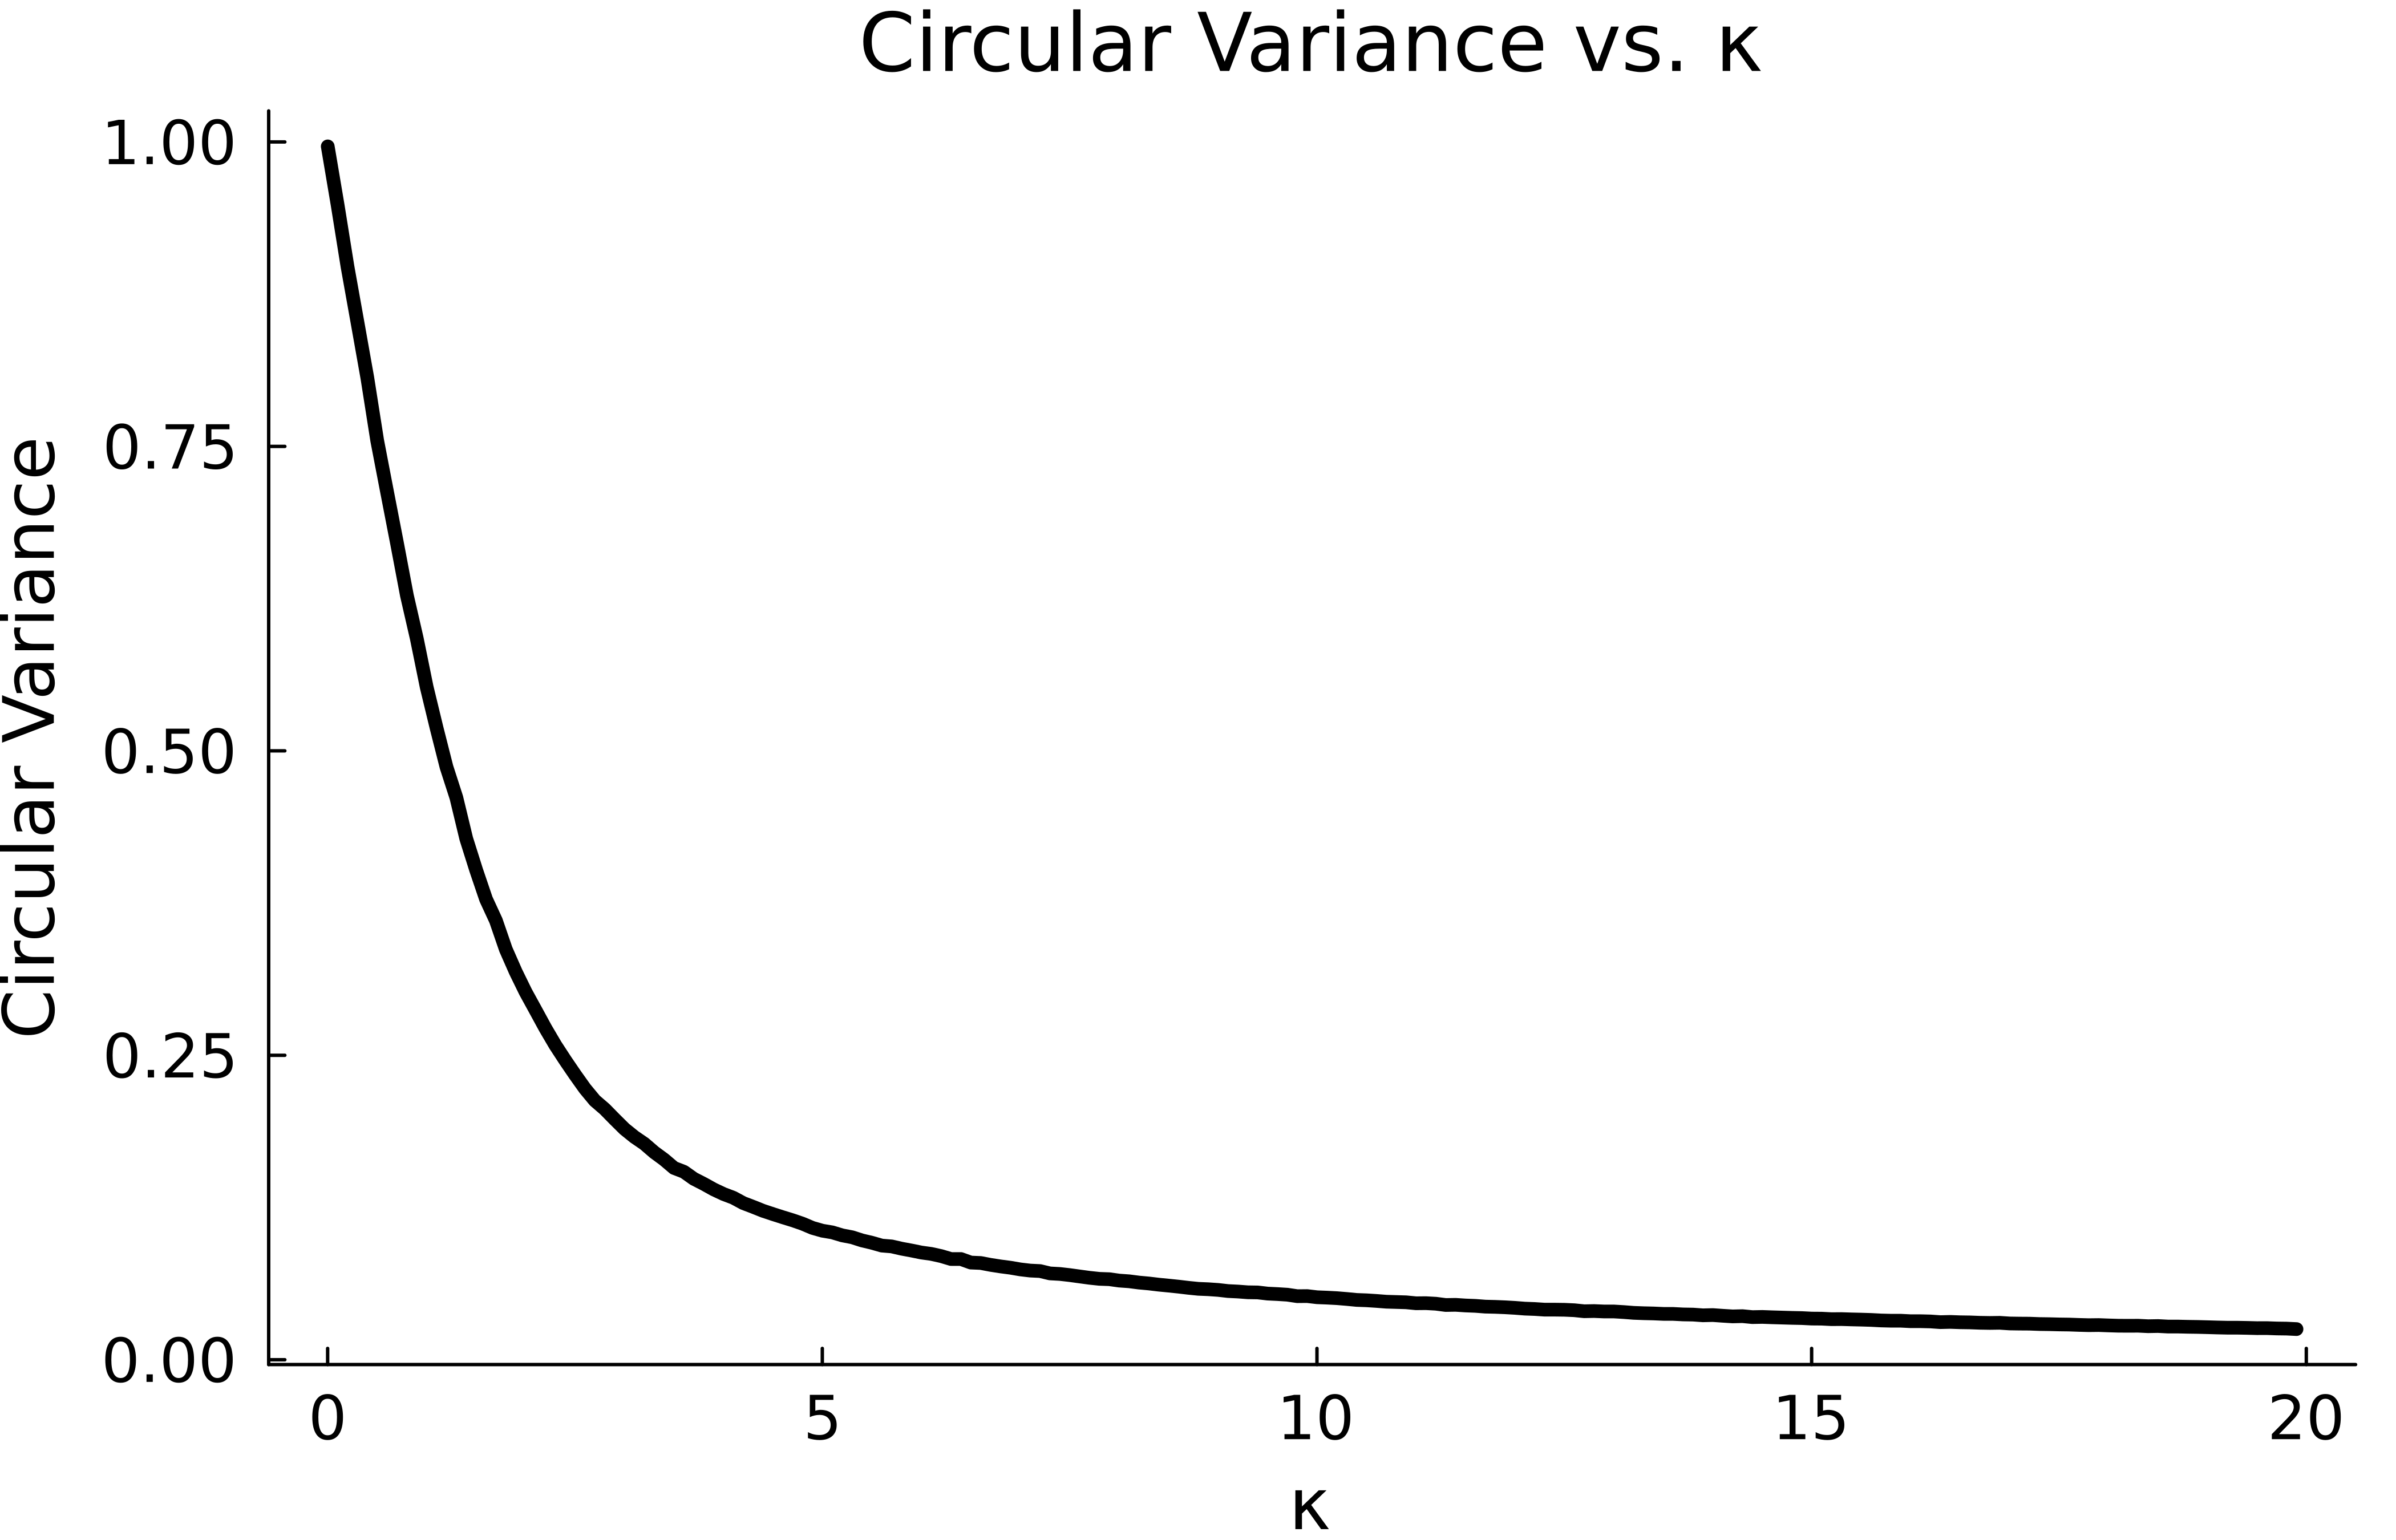

In [3]:
begin
	using Distributions, CircStats

	kappa_values = 0.001:0.1:20
	circ_var_values = map(κ -> 1.0 - circ_r(wrap_phase.(rand(VonMises(0.0, κ), 100_001))), kappa_values)

	plot(kappa_values, circ_var_values, xlabel="κ", ylabel="Circular Variance", title="Circular Variance vs. κ", legend=false, linewidth=4, color=:black, grid=false, tickfontsize=12, xguidefontsize=14, yguidefontsize=14, titlefontsize=16, dpi=600, size=(700, 450))
end

In short, low variance ($V$ close to 0) corresponds to high concentration (large $\kappa$), indicating tightly clustered, coherent phases. High variance ($V$ near 1) implies low concentration (small $\kappa$), as in a uniform phase distribution. This relationship is visualized in Figure 5.

Theoretically, if phase unwrapping were reliably possible, one could fit a traditional Gaussian to the unwrapped phases and estimate standard deviation $\sigma$ in radians or degrees, giving familiar uncertainty metrics. Bakulin et al. (2024) derived numerical correspondences between $\kappa$ and $\sigma$ for such cases. However, unwrapping is rarely feasible or stable for noisy seismic data in practice.

Therefore, becoming fluent in interpreting wrapped-domain quantities like circular variance ($V$) and the von Mises concentration parameter ($\kappa$) is essential. Both describe phase dispersion, but differently. Circular variance is a general-purpose metric that can be computed for any phase distribution, whereas $\kappa$ is specific to the von Mises model. $V$ is often more robust and intuitive for practical diagnostics in field data due to its bounded range between 0 and 1. In contrast, $\kappa$ ranges from 0 to $\infty$ and can exhibit large fluctuations between neighboring samples in noisy settings.

Nonetheless, when the von Mises model is assumed, $V$ and $\kappa$ are tightly linked through the mean resultant length $\bar{R}$ and are analytically or graphically interconvertible (see Figure 5 and Table 1).

In short, the von Mises distribution gives us more than a fit — it offers a framework. It allows us to interpret phase coherence, model uncertainty, and detect reliable signal content across frequencies. With this model in hand, we are now ready to return to our earlier examples, this time through the lens of circular statistics, and see what was hidden in plain sight.

In [ ]:
function variance_to_kappa(V::Real)
    R = 1 - V
    if R < 1e-8
        return 0.0
    elseif R < 0.53
        return 2R + R^3 + (5R^5)/6
    elseif R < 0.85
        return -0.4 + 1.39R + 0.43/(1 - R)
    else
        return 1 / (R^3 - 4R^2 + 3R)
    end
end

function add_circle_axes!(p; r=1.0)
    tt = range(0, 2π; length=361)
    plot!(p, r*cos.(tt), r*sin.(tt), lc=:black, lw=3, label=false)
    plot!(p, [-r, r], [0, 0], lc=:black, lw=3, label=false)
    plot!(p, [0, 0], [-r, r], lc=:black, lw=3, label=false)
    return p
end

function plot_vectors(θ; step=5, col=:lightgreen, ttl="")
	xs, ys = cos.(θ), sin.(θ)
	R_bar = circ_r(θ)
	mean_dir, = circ_mean(θ)
	R_bar_vector = (R_bar*cos(mean_dir), R_bar*sin(mean_dir))
	idx = 1:step:length(xs)

	p = quiver(zeros(length(idx)), zeros(length(idx)); quiver=(xs[idx], ys[idx]), aspect_ratio=1, legend=false, grid=false, xlims=(-1.1,1.1), ylims=(-1.1,1.1), arrow=true, lw=1, linecolor=col, axis=false, title=ttl)

	add_circle_axes!(p)
	annotate!(p, [(1.05, 0.00, text("0", 14)), (-1.08, 0.00, text("-π,\n π", 14, :center)), (0.00, 1.08, text("π/2", 14, :center)), (0.00, -1.10, text("-π/2", 14, :center))])

	quiver!(p, [0.0], [0.0]; quiver=([R_bar_vector[1]], [R_bar_vector[2]]), arrow=true, lw=6, linecolor=:green, label=false)
	return p
end

function c_hist(θ; nbins=30, colR=:green, ttl="")

    # Histogram edges on [-π, π]
    edges = range(-π, π; length=nbins+1)
    h = fit(Histogram, θ, edges)

    counts  = h.weights
    centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
    widths  = diff(edges)

    # Normalize radii 
    maxc = maximum(counts)
    r = maxc > 0 ? counts ./ maxc : zeros(length(counts))
    
    # Base plot
    p = plot(aspect_ratio=1, legend=false, grid=false,
             xlims=(-1.1, 1.1), ylims=(-1.1, 1.1),
             title=ttl, axis=false)

    for (c, w, rr) in zip(centers, widths, r)
        t1 = c - w/2
        t2 = c + w/2
        tseg = range(t1, t2; length=12)

        x = vcat(0.0, rr*cos.(tseg), 0.0)
        y = vcat(0.0, rr*sin.(tseg), 0.0)

        plot!(p, x, y, seriestype=:shape, fc=:white, lc=:black, lw=1, label=false)
    end

    add_circle_axes!(p)

    annotate!(p, [(1.05, 0.00, text("0", 14)), (-1.08, 0.00, text("-π,\n π", 14, :center)), (0.00, 1.08, text("π/2", 14, :center)), (0.00, -1.10, text("-π/2", 14, :center))])
    
    R_bar = circ_r(θ)
	mean_dir, = circ_mean(θ)
	R_bar_vector = (R_bar*cos(mean_dir), R_bar*sin(mean_dir))
    # Resultant vector overlay
    quiver!(p, [0.0], [0.0]; quiver=([R_bar_vector[1]], [R_bar_vector[2]]), arrow=true, lw=6, linecolor=:green, label=false)

    return p
end

variance_to_kappa (generic function with 1 method)

In [17]:
V1, V2 = 0.8, 0.1
κ1, κ2 = variance_to_kappa(V1), variance_to_kappa(V2)
R1 = 1-V1
R2 = 1-V2
	
d1, d2 = VonMises(0.0, κ1), VonMises(0.0, κ2)
phase1 = rand(d1, 1000)
phase2 = rand(d2, 1000);

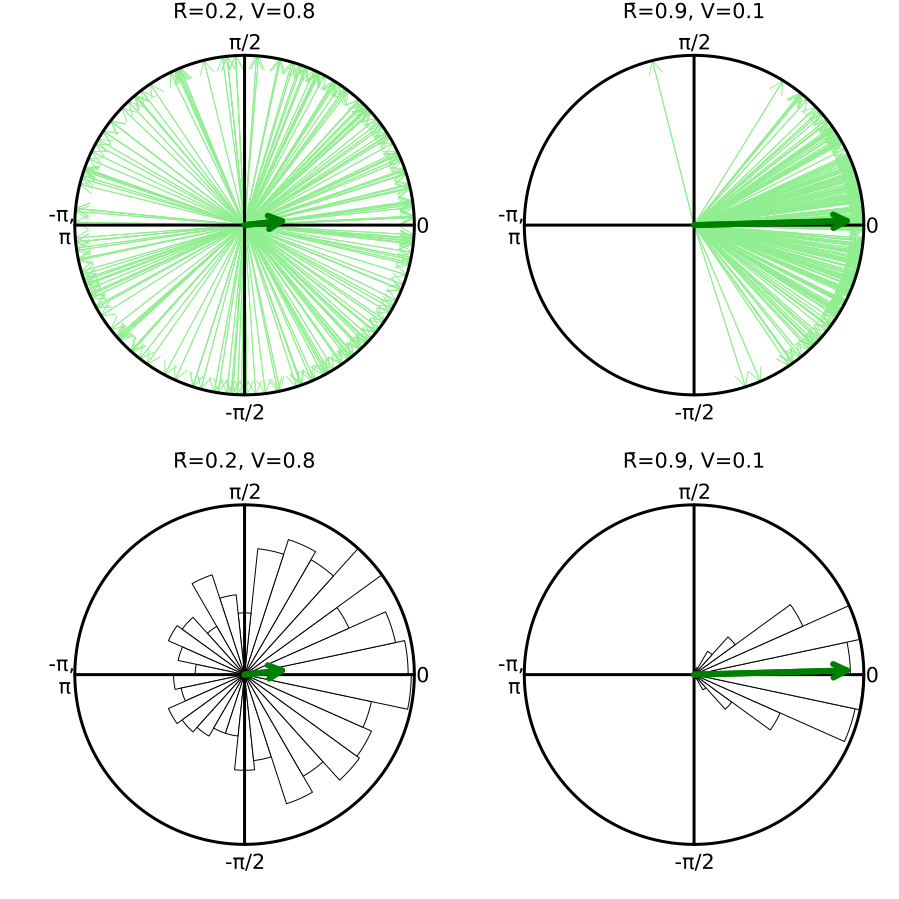

In [18]:
using StatsBase
V1, V2 = 0.8, 0.1
κ1, κ2 = variance_to_kappa(V1), variance_to_kappa(V2)
R1 = 1-V1
R2 = 1-V2
	
d1, d2 = VonMises(0.0, κ1), VonMises(0.0, κ2)
phase1 = rand(d1, 1000)
phase2 = rand(d2, 1000);

va = plot_vectors(phase1; ttl="R̄=$(round(R1,digits=2)), V=$V1")
vb = plot_vectors(phase2; ttl="R̄=$(round(R2,digits=2)), V=$V2")
ca = c_hist(phase1; nbins=30, ttl="R̄=$(round(R1,digits=2)), V=$V1")
cb = c_hist(phase2; nbins=30, ttl="R̄=$(round(R2,digits=2)), V=$V2")

plot(va, vb, ca, cb, layout=(2,2), size=(900,900))

# **Application of circular statistics to the additive white noise example**


Figures  1c–1h  and  1k–1p  show  the  application  of  circular  statistics to the initial synthetic example with additive white noise. We accumulated phase ensembles from 1000 traces and analyzed them frequency by frequency. Suddenly, the patterns that previously appeared confusing now begin to make sense. The circular mean aligns precisely with the true signal phase, and the observed phase distributions fit well with the von Mises model (equation 5).Traditionally, such phases are studied using linear histograms (Figures 1c and 1d). However, this approach fails to capture the true nature of phase behavior, especially in noisy environments. For instance, the apparent bimodality seen at 60 Hz (Figure 1d) arises not from a physical phenomenon but from an artifact of the linear representation. Seismic phase is fundamentally circular, naturally bounded within [−π, π]. Ignoring that structure leads to misleading interpretations.The story becomes much clearer when the same distributions are  displayed  on  a  circular  scale  using  rose  diagrams  (Figures  1g–1h and 1o–1p). What appeared bimodal on the line now forms a single, coherent cluster around the true phase direction. Figures 1h  and  1p  visually  resemble  Figures  1g  and  1o,  except  for  the  mean rotation, which reflects natural changes in signal phase with frequency. These rose diagrams resolve visual ambiguity and allow for direct estimation of the signal phase using the circular mean. Each unit vector on the circle corresponds to a trace’s phase at a given frequency. Their average direction provides a robust estimate of the dominant phase, so no unwrapping or modeling is needed. As  expected  from  white  noise,  the  variance  (quantified  via  the von Mises κ or circular variance V ) remains constant across frequencies. What changes is the signal phase itself, which rotates naturally from frequency to frequency. This example demonstrates how circular statistics reveal structure and coherence hidden by traditional methods, clarifying what initially appeared as disor-dered phase chaos.